Question 1 : What is the fundamental idea behind ensemble techniques? How does
bagging differ from boosting in terms of approach and objective?

Answer:
The fundamental idea behind ensemble techniques is to combine multiple individual models (often called weak learners) to create a more accurate, robust, and stable final model. The goal is that by aggregating the predictions of several models, the ensemble reduces variance, bias, or both, compared to any single model.

diffrence betwwen bagging and boasting-

>>Bagging (Bootstrap Aggregating):
Trains multiple models independently on different random subsets of the data (with replacement).
Reduces variance and helps prevent overfitting.
All models contribute equally to the final prediction (simple averaging or majority voting).

boasting:
Trains models sequentially, where each model learns from the errors of the previous ones.

Reduces both bias and variance by focusing more on difficult-to-predict instances.

Models are weighted based on their accuracy — better models have more influence.

Question 2: Explain how the Random Forest Classifier reduces overfitting compared to
a single decision tree. Mention the role of two key hyperparameters in this process.

Answer:
A Random Forest Classifier reduces overfitting by combining the predictions of multiple decision trees instead of relying on a single tree. Each tree is trained on a different random subset of the training data and features, which introduces diversity among the trees. When their predictions are averaged (or voted on), the random errors of individual trees tend to cancel out, resulting in a more generalized and stable model.
Two key hyperparameters that help in this process:


Represents the number of trees in the forest.

More trees generally improve performance by reducing variance, as the ensemble prediction becomes more stable.

max_features:

Determines the number of features considered for splitting at each node.

Limiting features increases tree diversity and reduces correlation between trees, helping prevent overfitting.

Question 3: What is Stacking in ensemble learning? How does it differ from traditional
bagging/boosting methods? Provide a simple example use case.

Answer:
Stacking (Stacked Generalization) is an ensemble learning technique that combines multiple models (called base learners) using another model (called a meta-learner or blender) to improve predictive performance. Instead of simply averaging or voting like in bagging or boosting, stacking learns how to best combine the predictions of different models.

diffrence betwwen stacking from tradition boasting and bagging,

stacking:
Combines different types of models using a meta-learner.
Base models are trained in parallel; meta-model learns from their outputs.
boasting and bagging:

Bagging (Bootstrap Aggregating): Trains multiple models independently on different random subsets of the data (with replacement). Reduces variance and helps prevent overfitting. All models contribute equally to the final prediction (simple averaging or majority voting).

boasting: Trains models sequentially, where each model learns from the errors of the previous ones.

Reduces both bias and variance by focusing more on difficult-to-predict instances.

Models are weighted based on their accuracy — better models have more influence.

Question 4
What is the OOB Score in Random Forest, and why is it useful? How does it help in model evaluation without a separate validation set

Answer:
The OOB (Out-of-Bag) Score is an internal validation metric used in Random Forest to estimate model performance without needing a separate validation or test dataset.

Explanation:
In Random Forest, each tree is trained on a bootstrap sample — a random subset of the training data created with replacement. This means that, on average, about 63% of the data is used to train a particular tree, while the remaining 37% of the data is left out (not used for training that tree). These unused samples are called Out-of-Bag (OOB) samples.

it is useful because

1>It provides a built-in cross-validation mechanism.

2>It helps evaluate model performance without requiring a separate validation set, saving both time and data.

3>It gives a reliable estimate of generalization error since the OOB samples act like unseen data for each tree.

it help in modal evuluation:

Each tree makes predictions on its OOB samples (data not seen during its training).

The model aggregates these OOB predictions for all trees.

The accuracy (or error) computed using these aggregated predictions is the OOB Score

Question 5: Compare AdaBoost and Gradient Boosting in terms of:
● How they handle errors from weak learners
● Weight adjustment mechanism
● Typical use cases

Adaboost:

1.Focuses more on the samples that were misclassified by previous weak learners. Each subsequent model gives higher importance to difficult (misclassified) instances.

2.Adjusts the weights of individual samples — increasing weights for misclassified ones and decreasing for correctly classified ones.

3.Works well for binary classification and simple datasets (e.g., spam detection, face recognition).

Gradient:

1.Fits each new weak learner to the residual errors (gradients) of the previous model to minimize the overall loss function directly.

2.Adjusts the predictions of the ensemble by taking a step in the direction that reduces the loss function (using gradient descent).

3.Suitable for complex regression and classification tasks (e.g., predicting house prices, customer churn, credit risk).

Question 6:Why does CatBoost perform well on categorical features without requiring
extensive preprocessing? Briefly explain its handling of categorical variables.

Answer:
CatBoost (Categorical Boosting) performs well on categorical features because it is specifically designed to handle categorical data internally, eliminating the need for manual preprocessing steps like one-hot encoding or label encoding.

How CatBoost handles categorical variables:

Target-Based Encoding with Permutations:

Instead of converting categories into numeric codes directly, CatBoost replaces each categorical value with the average target value (e.g., mean of the label) for that category.

To prevent data leakage, CatBoost uses ordered permutations — meaning it calculates these averages using only the previous examples in the dataset, not future ones.

Efficient Combination of Features:

CatBoost automatically creates combinations of categorical features during training, helping the model capture complex relationships between categories.

Why it performs well:

Avoids overfitting and target leakage through ordered encoding.

Eliminates the need for heavy preprocessing like one-hot encoding.

Efficiently captures category interactions and patterns.


Question 7: KNN Classifier Assignment: Wine Dataset Analysis with
Optimization
Task:
1. Load the Wine dataset (sklearn.datasets.load_wine()).
2. Split data into 70% train and 30% test.
3. Train a KNN classifier (default K=5) without scaling and evaluate using:
a. Accuracy
b. Precision, Recall, F1-Score (print classification report)
4. Apply StandardScaler, retrain KNN, and compare metrics.
5. Use GridSearchCV to find the best K (test K=1 to 20) and distance metric
(Euclidean, Manhattan).
6. Train the optimized KNN and compare results with the unscaled/scaled versions.

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)

y_pred_default = knn_default.predict(X_test)
print(" KNN without Scaling:")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("Classification Report:\n", classification_report(y_test, y_pred_default))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
print("\n KNN with StandardScaler:")
print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("Classification Report:\n", classification_report(y_test, y_pred_scaled))

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("\n Best Parameters from GridSearchCV:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred_optimized = best_knn.predict(X_test_scaled)

print("\n Optimized KNN Model Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_optimized))
print("Classification Report:\n", classification_report(y_test, y_pred_optimized))


 KNN without Scaling:
Accuracy: 0.7222222222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       0.78      0.67      0.72        21
           2       0.50      0.60      0.55        15

    accuracy                           0.72        54
   macro avg       0.72      0.72      0.72        54
weighted avg       0.74      0.72      0.73        54


 KNN with StandardScaler:
Accuracy: 0.9444444444444444
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      0.86      0.92        21
           2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54


 Best Parameters from GridSearchCV: {'metric': 'euclidean', 'n_neighbors': 11}
Bes

Question 8 : PCA + KNN with Variance Analysis and Visualization
Task:
1. Load the Breast Cancer dataset (sklearn.datasets.load_breast_cancer()).
2. Apply PCA and plot the scree plot (explained variance ratio).
3. Retain 95% variance and transform the dataset.
4. Train KNN on the original data and PCA-transformed data, then compare
accuracy.
5. Visualize the first two principal components using a scatter plot (color by class).

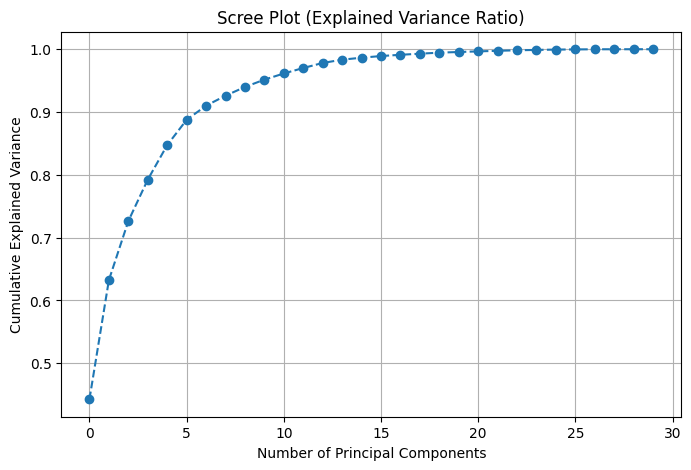

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance_ratio), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot (Explained Variance Ratio)')
plt.grid(True)
plt.show()


Question 9:KNN Regressor with Distance Metrics and K-Value
Analysis
Task:
1. Generate a synthetic regression dataset
(sklearn.datasets.make_regression(n_samples=500, n_features=10)).
2. Train a KNN regressor with:
a. Euclidean distance (K=5)
b. Manhattan distance (K=5)
c. Compare Mean Squared Error (MSE) for both.
3. Test K=1, 5, 10, 20, 50 and plot K vs. MSE to analyze bias-variance tradeoff

 KNN Regressor Comparison (K=5):
Euclidean Distance MSE: 4837.04
Manhattan Distance MSE: 5428.59


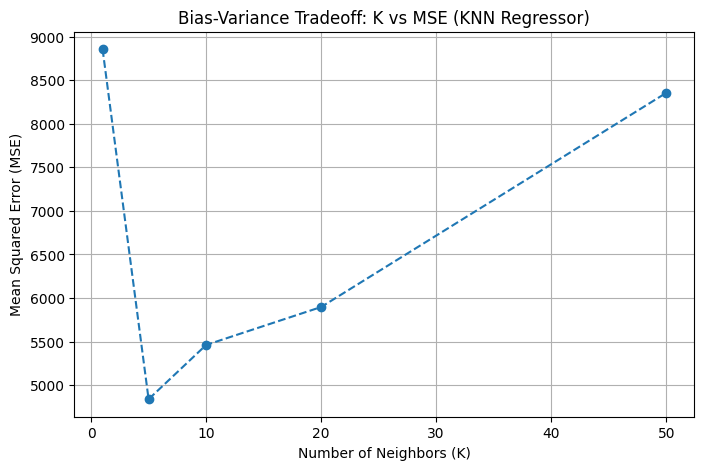

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

X, y = make_regression(n_samples=500, n_features=10, noise=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_euclidean = KNeighborsRegressor(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test_scaled)

knn_manhattan = KNeighborsRegressor(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)

mse_euclidean = mean_squared_error(y_test, y_pred_euclidean)
mse_manhattan = mean_squared_error(y_test, y_pred_manhattan)

print(" KNN Regressor Comparison (K=5):")
print(f"Euclidean Distance MSE: {mse_euclidean:.2f}")
print(f"Manhattan Distance MSE: {mse_manhattan:.2f}")

k_values = [1, 5, 10, 20, 50]
mse_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    mse_scores.append(mean_squared_error(y_test, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_scores, marker='o', linestyle='--')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Bias-Variance Tradeoff: K vs MSE (KNN Regressor)')
plt.grid(True)
plt.show()
